In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch 
import torch.nn as nn
import torch.optim as optim
import cv2
from tqdm.notebook import trange, tqdm
import random
from tqdm.auto import tqdm

import time

import sys, os
BASE = os.getcwd()  
if BASE not in sys.path:
    sys.path.append(BASE)
    
sys.path.append('../')
from funcs import *  

In [2]:
def load_pred_hr(
    patch_num,
    epoch,
    base_dir="./NoiseComp",
    resolution="",
    seed="seed_42",
):
    """
    Load net_0_pred_h.npy and net_0_pred_r.npy for a given Patch and epoch.

    Parameters
    ----------
    patch_num : int or str
        Patch size, e.g. 16, 32  -> Patch16, Patch32
    epoch : int or str
        Training epoch, e.g. 5000 -> epoch_5000
    base_dir : str
        Base directory up to 20251219
    resolution : str
        The fixed middle-level directory (default: "16")
    seed : str
        Seed folder name (default: "seed_42")

    Returns
    -------
    pred_h : np.ndarray
    pred_r : np.ndarray
    full_path : str
    """

    patch_dir = f"Noise{patch_num}"
    epoch_dir = f"epoch_{epoch}"

    full_path = os.path.join(
        base_dir,
        patch_dir,
        resolution,
        seed,
        epoch_dir,
    )

    h_path = os.path.join(full_path, "net_0_pred_h.npy")
    r_path = os.path.join(full_path, "net_0_pred_r.npy")

    if not os.path.isfile(h_path):
        raise FileNotFoundError(f"Missing file: {h_path}")
    if not os.path.isfile(r_path):
        raise FileNotFoundError(f"Missing file: {r_path}")

    pred_h = np.load(h_path)
    pred_r = np.load(r_path)

    return pred_h, pred_r#, full_path


In [3]:
n_pts = 928
pattern_shape = 768
file_path = '../Blender_test/'
relf_path = 'reflectance.png'
heig_path = 'heightmap.png'

# --- height ---
height_np = cv2.imread(file_path + heig_path, cv2.IMREAD_GRAYSCALE)  # (H,W)
height_np = cv2.resize(height_np, (n_pts, n_pts))
height_np = height_np.astype(np.float32)
height_np = (height_np / (height_np.max() + 1e-12)) * 40.0

height_map = pad_to_size(torch.from_numpy(height_np), (int(pattern_shape*1.5), int(pattern_shape*1.5))).to(torch.float32)

# cv2.resize needs numpy
height_map_np = height_map.cpu().numpy()  # (H,W), float32
height_map_np = cv2.resize(height_map_np, (pattern_shape, pattern_shape), interpolation=cv2.INTER_LINEAR)

# back to torch
height_map = torch.from_numpy(height_map_np).to(torch.float32)
# height_map = height_map.to(device)

# --- reflectance ---
refl_np = cv2.imread(file_path + relf_path)          # (H, W, 3), BGR, uint8
refl_np = cv2.cvtColor(refl_np, cv2.COLOR_BGR2RGB)  # (H, W, 3), RGB
refl_np = cv2.resize(refl_np, (n_pts, n_pts))
refl_np = refl_np.astype(np.float32)

refl_np = refl_np / (refl_np.max() + 1e-12)          # (H, W, 3)

refl_pad = pad_to_size(
    torch.from_numpy(refl_np),                       # (H, W, 3)
    (int(pattern_shape * 1.5), int(pattern_shape * 1.5))
).numpy()                                            # (H2, W2, 3)

refl_pad = cv2.resize(
    refl_pad,
    (pattern_shape, pattern_shape),
    interpolation=cv2.INTER_LINEAR
)                                                    # (H, W, 3)

# ========== back to torch, channel-first ==========
reflectance = torch.from_numpy(refl_pad) \
    .permute(2, 0, 1) \
    .to(torch.float32)                               # (3, H, W)



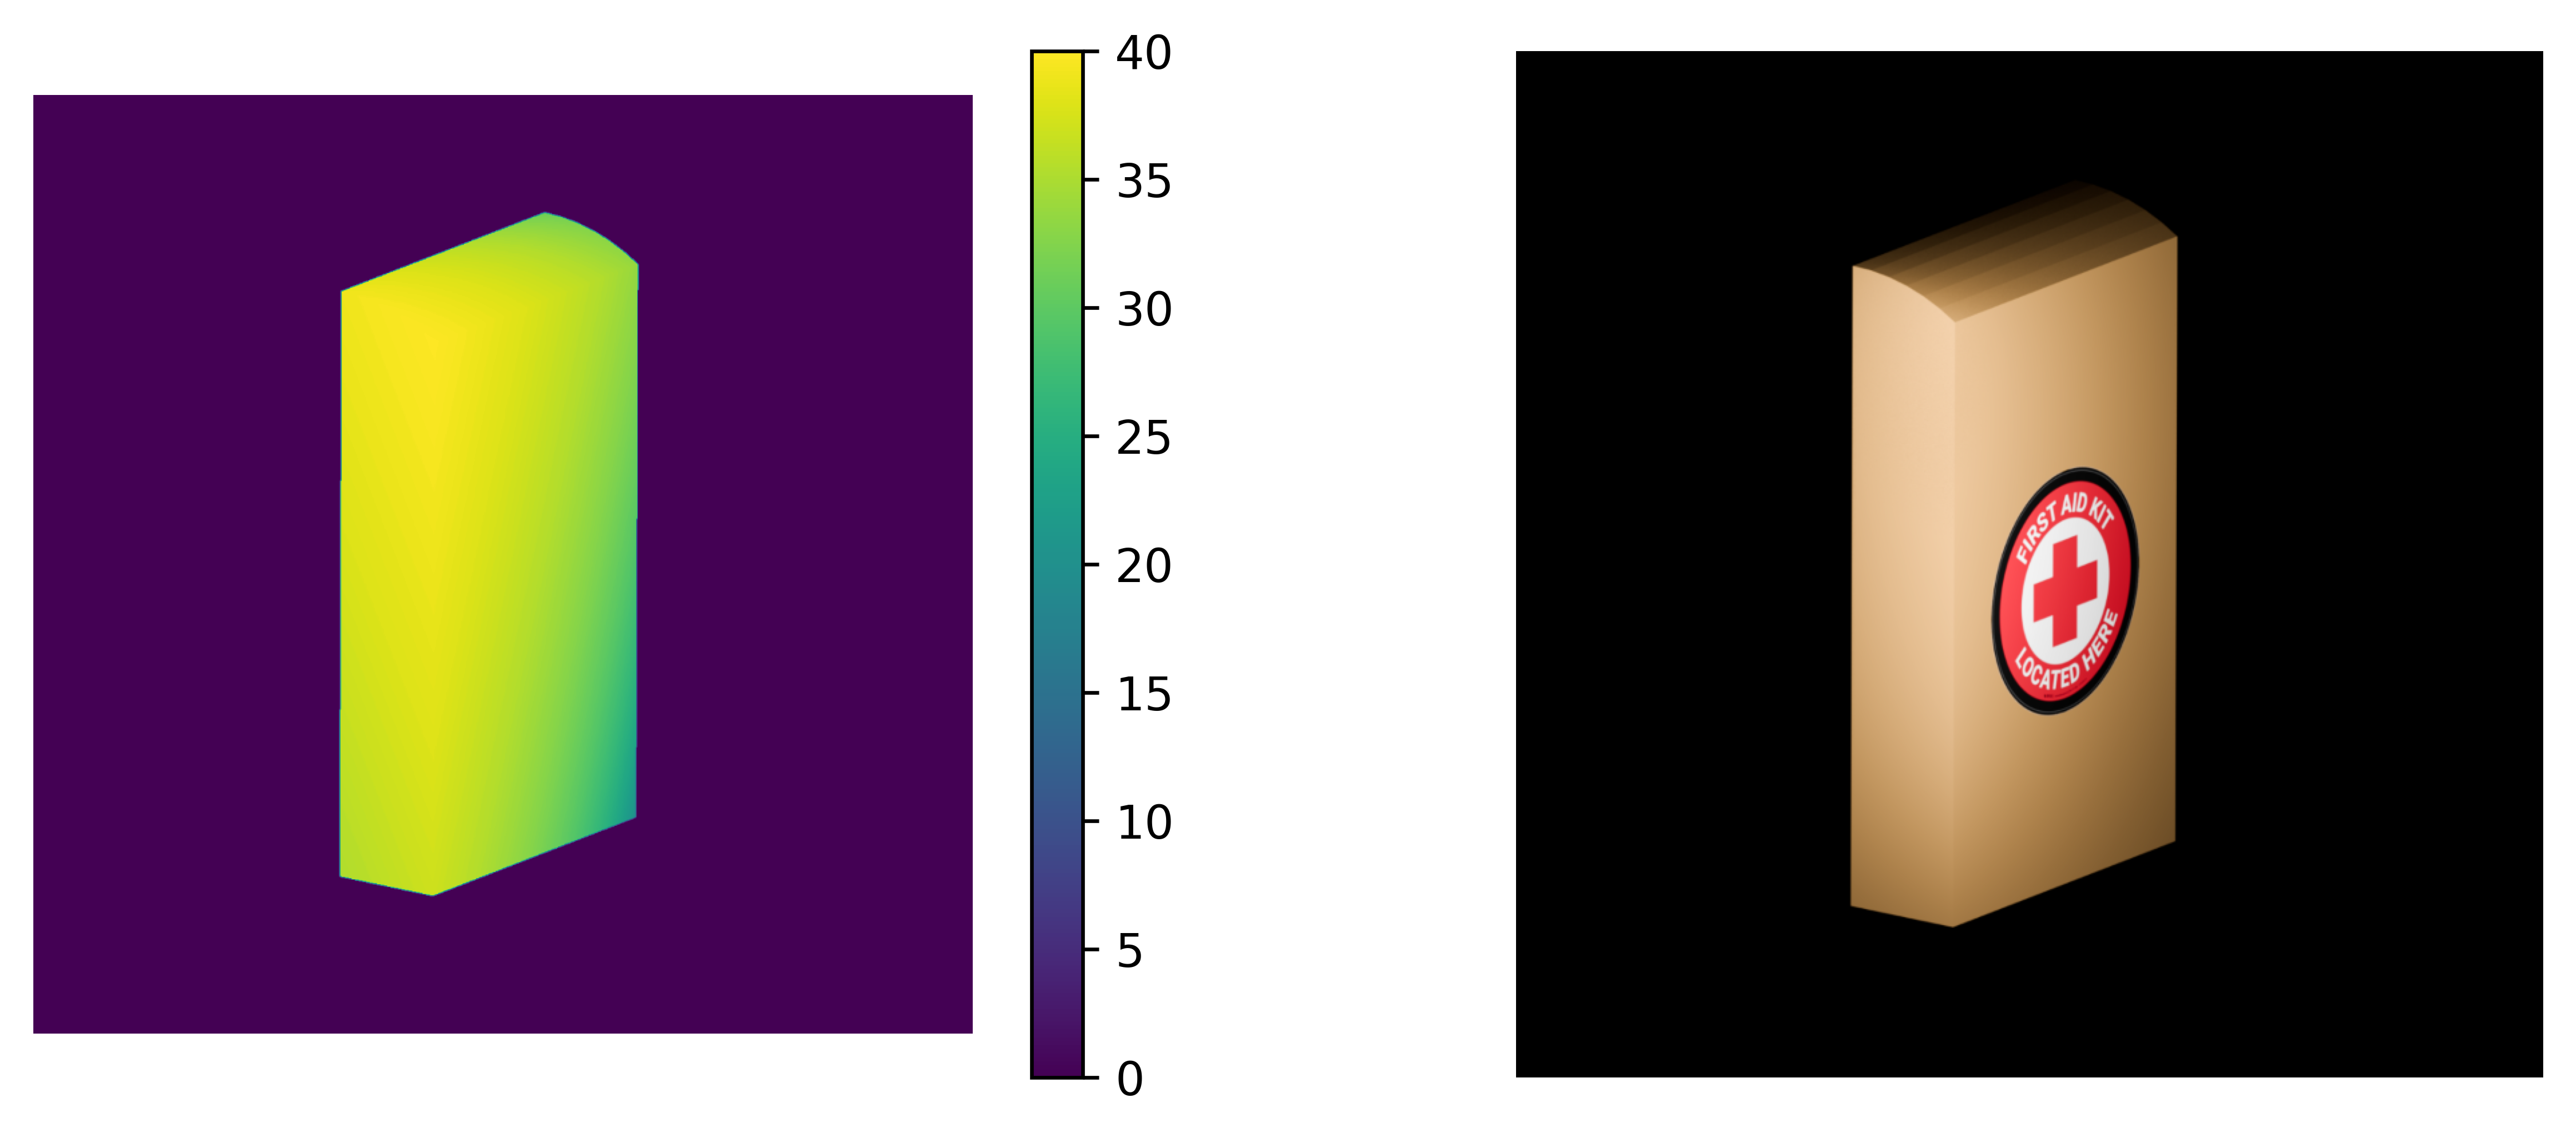

In [4]:
fig = plt.figure(figsize = (10,4),dpi = 600)
plt.subplot(121)
plt.imshow(height_map)
plt.colorbar()
plt.axis("off")
# plt.axis('off')
plt.subplot(122)
plt.imshow(reflectance.permute(1,2,0))
# plt.colorbar()
plt.axis("off")
plt.show()

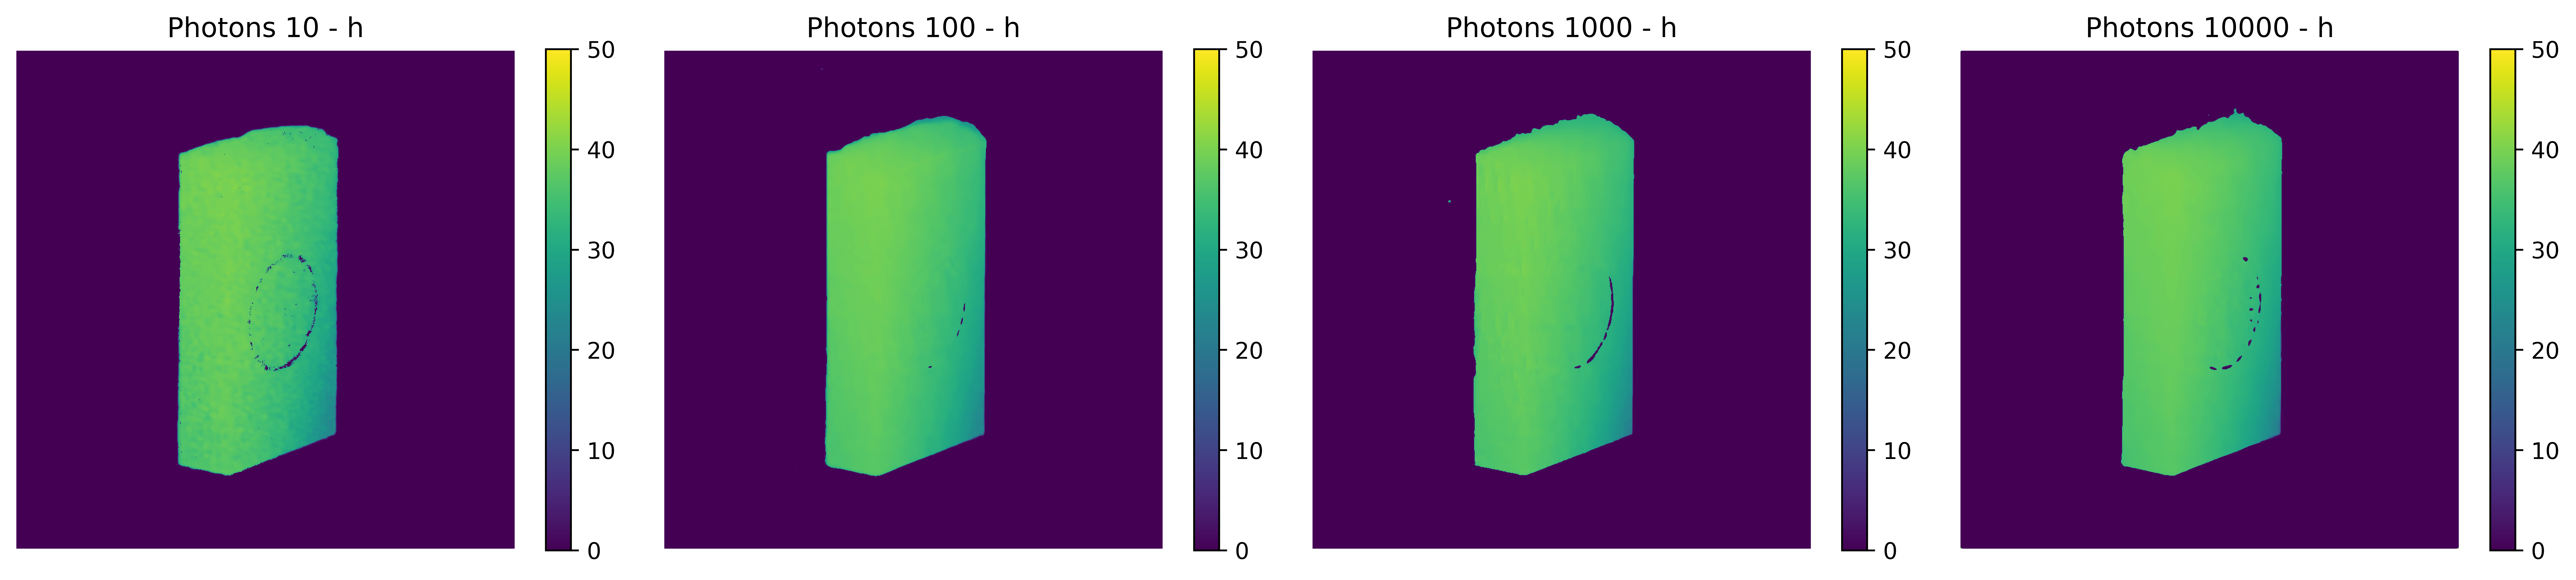

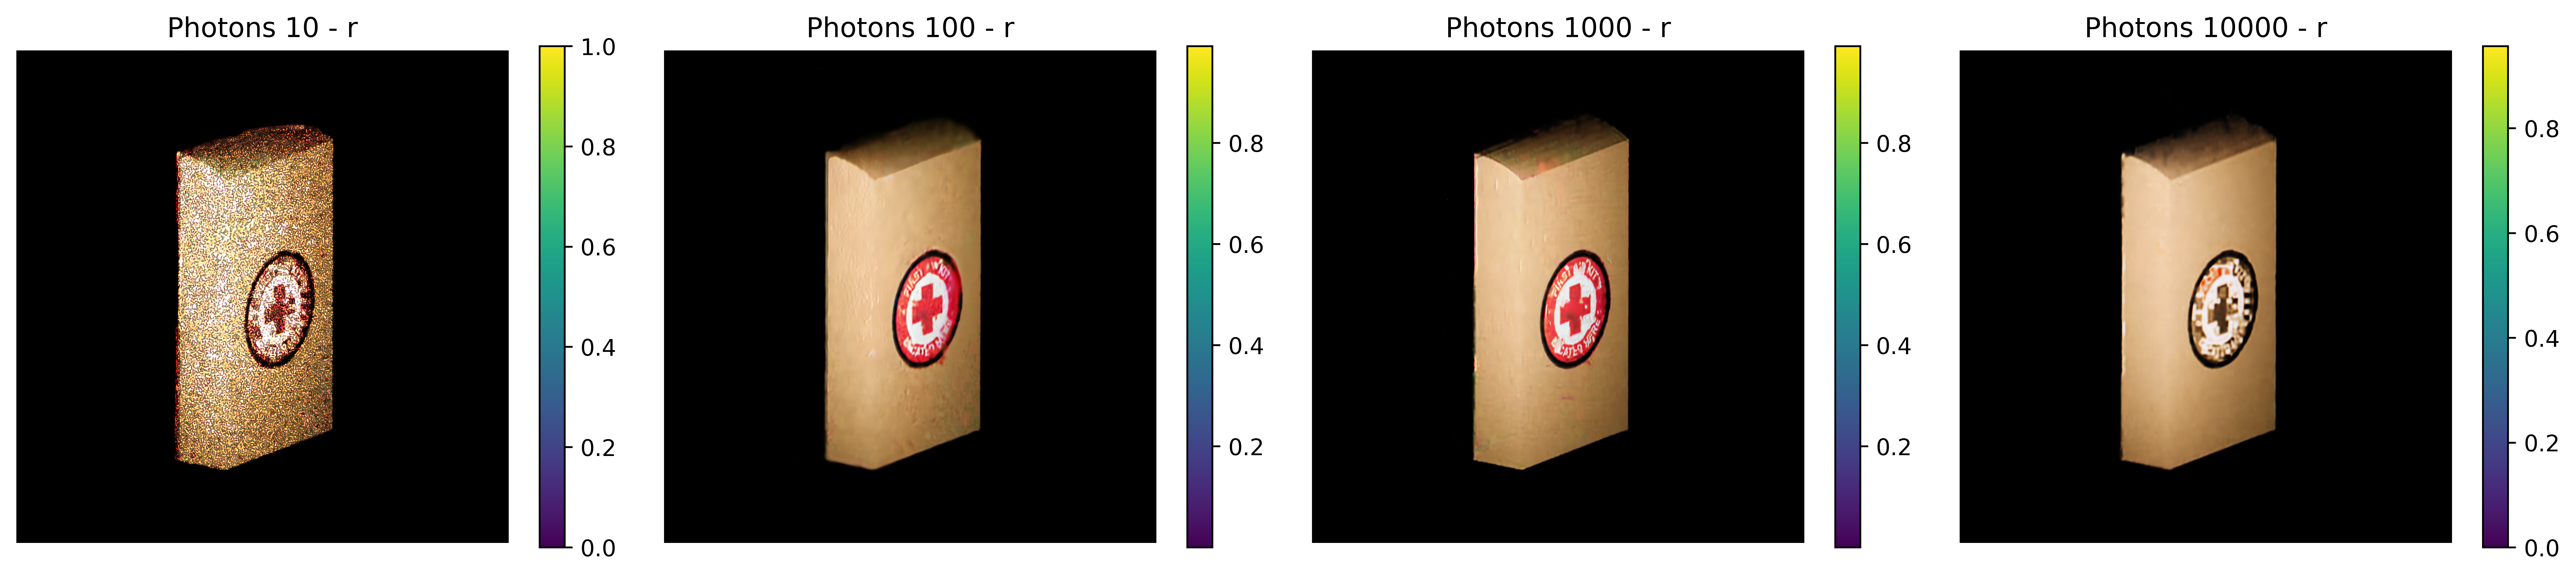

In [5]:
patches = [10, 100, 1000, 10000]
epoch = 5000

# --- load ---
h_list = []
r_list = []
for p in patches:
    h, r = load_pred_hr(patch_num=p, epoch=epoch)
    h_list.append(h)
    r_list.append(r)

def to_imshow_array(x):
    """
    Convert array into a shape matplotlib can imshow:
    - (H,W) -> keep
    - (H,W,3/4) -> keep
    - (3/4,H,W) -> transpose to (H,W,3/4)
    - (H,W,1) or (1,H,W) -> squeeze to (H,W)
    Otherwise -> raise error
    """
    x = np.asarray(x)

    if x.ndim == 2:
        return x

    if x.ndim == 3:
        # HWC
        if x.shape[-1] in (1, 3, 4):
            return x.squeeze(-1) if x.shape[-1] == 1 else x

        # CHW
        if x.shape[0] in (1, 3, 4):
            x = np.transpose(x, (1, 2, 0))
            return x.squeeze(-1) if x.shape[-1] == 1 else x

    raise TypeError(f"Cannot convert shape {x.shape} to a valid image for imshow.")


# =========================
# Figure 1: Height (h)
# colorbar unified to max=50
# =========================
plt.figure(figsize=(4 * len(patches), 3.5), dpi = 600)

for i, p in enumerate(patches, start=1):
    plt.subplot(1, len(patches), i)
    img = to_imshow_array(h_list[i - 1])
    plt.imshow(img, vmin=0, vmax=50)     # <-- 统一最大值 50
    plt.title(f"Photons {p} - h")
    plt.colorbar()
    plt.axis("off")

# plt.suptitle("Height Prediction (h)", fontsize=16)
plt.tight_layout()
plt.show()


# =========================
# Figure 2: Reflectance (r)
# auto fix CHW -> HWC
# =========================
plt.figure(figsize=(4 * len(patches), 3.5), dpi = 600)

for i, p in enumerate(patches, start=1):
    plt.subplot(1, len(patches), i)
    img = to_imshow_array(r_list[i - 1])

    plt.imshow(img)
    plt.title(f"Photons {p} - r")
    plt.colorbar()
    plt.axis("off")

# plt.suptitle("Reflectance Prediction (r)", fontsize=16)
plt.tight_layout()
plt.show()


In [6]:
def to_hw_float(x):
    """Convert prediction to (H,W) float32 numpy."""
    if hasattr(x, "detach"):  # torch tensor
        x = x.detach().cpu().numpy()
    x = np.asarray(x)
    if x.ndim == 3 and x.shape[0] == 1:
        x = x[0]
    if x.ndim == 3 and x.shape[-1] == 1:
        x = x[..., 0]

    if x.ndim != 2:
        raise TypeError(f"Expected a 2D height map after squeeze, got shape {x.shape}")
    return x.astype(np.float32)

def align_to_reference(pred_h, ref_h):
    """
    pred_h: predicted height (np or torch), any size
    ref_h: reference height as torch or np, shape (Href, Wref)
    Returns pred_resized (Href,Wref), ref (Href,Wref)
    """
    ref = to_hw_float(ref_h)
    pred = to_hw_float(pred_h)

    H, W = ref.shape
    pred_resized = cv2.resize(pred, (W, H), interpolation=cv2.INTER_LINEAR)
    return pred_resized, ref


In [7]:

diff_list = []
pred_aligned_list = []
ref_np = to_hw_float(height_map)   

for h_pred in h_list:
    pred_aligned, ref_aligned = align_to_reference(h_pred, ref_np)
    pred_aligned_list.append(pred_aligned)
    diff_list.append(pred_aligned - ref_aligned)

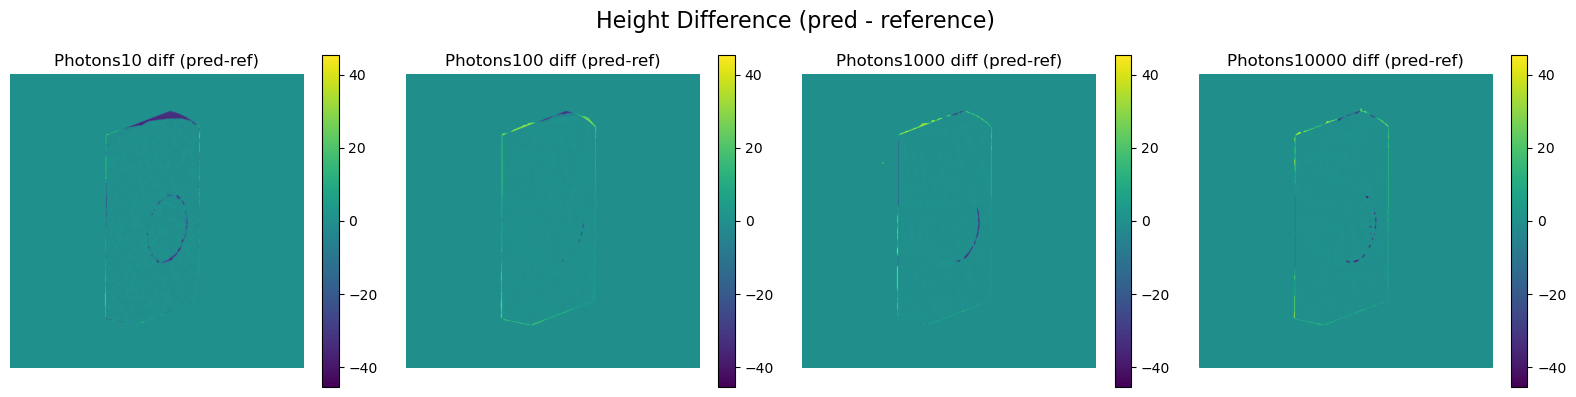

In [8]:

diff_list = []
pred_aligned_list = []
ref_np = to_hw_float(height_map)   

for h_pred in h_list:
    pred_aligned, ref_aligned = align_to_reference(h_pred, ref_np)
    pred_aligned_list.append(pred_aligned)
    diff_list.append(pred_aligned - ref_aligned)

plt.figure(figsize=(4 * len(patches), 4))

absmax = max(np.max(np.abs(d)) for d in diff_list) + 1e-12

for i, p in enumerate(patches, start=1):
    plt.subplot(1, len(patches), i)
    plt.imshow(diff_list[i-1], vmin=-absmax, vmax=absmax)
    plt.title(f"Photons{p} diff (pred-ref)")
    plt.colorbar()
    plt.axis("off")

plt.suptitle("Height Difference (pred - reference)", fontsize=16)
plt.tight_layout()
plt.show()


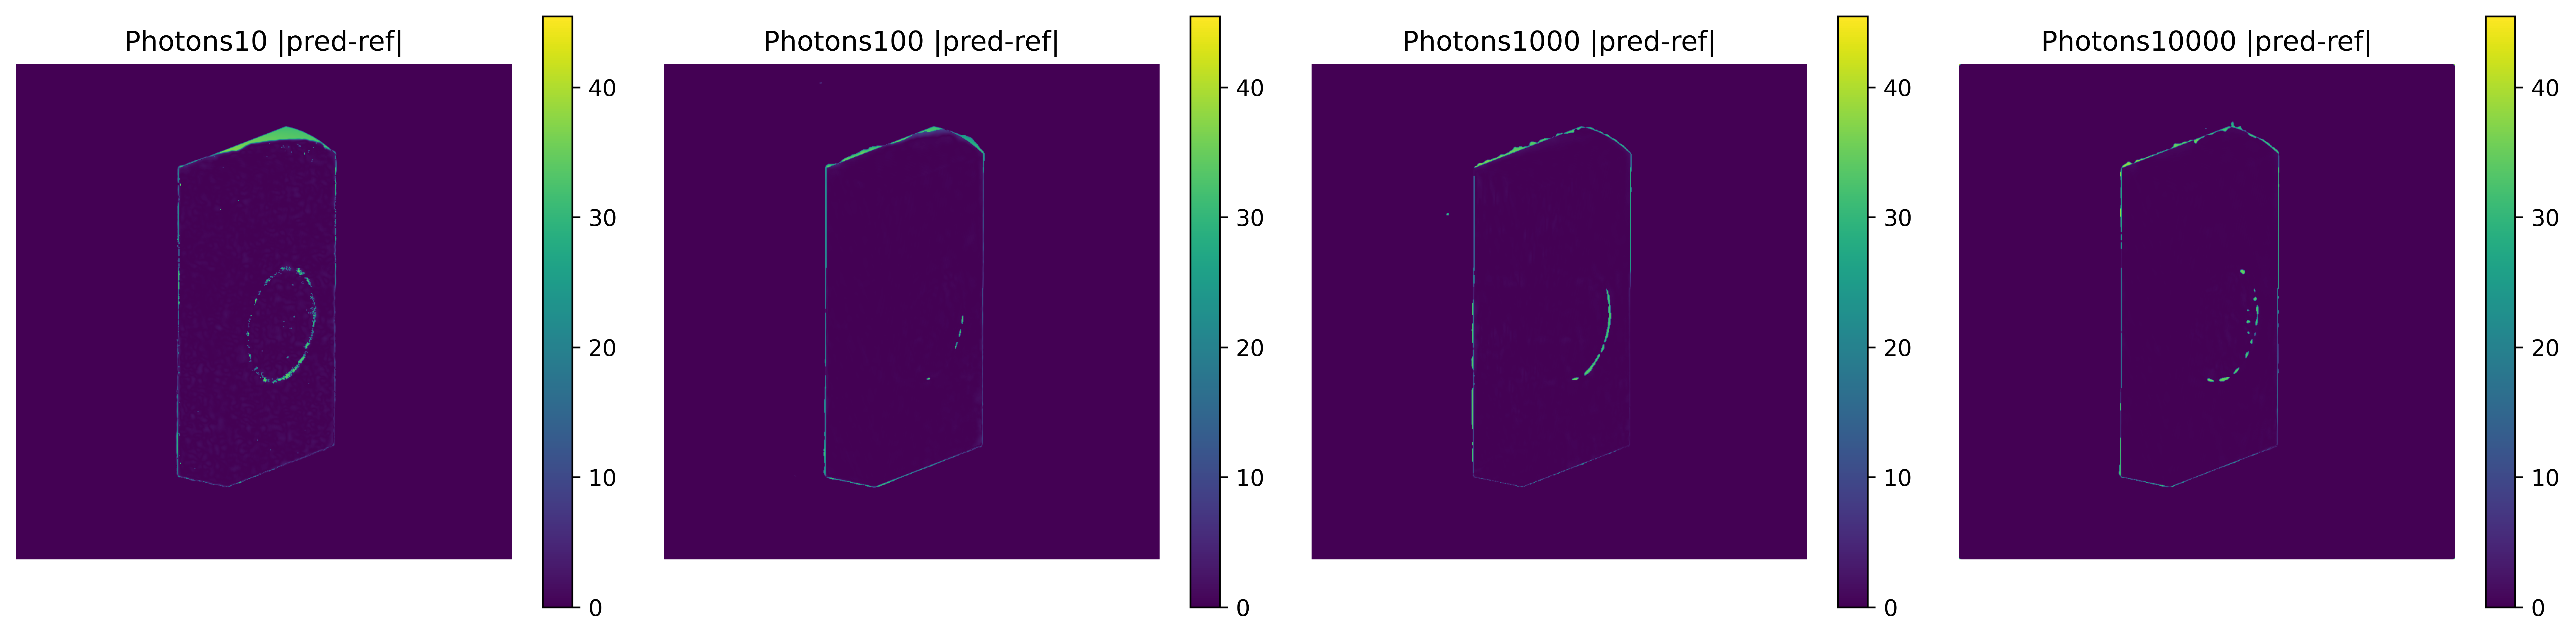

In [9]:
# diff_list: list of (H,W) arrays, each is pred-ref
absdiff_list = [np.abs(d) for d in diff_list]
absmax = max(np.max(ad) for ad in absdiff_list) + 1e-12

plt.figure(figsize=(4 * len(patches), 4),dpi = 600)

for i, p in enumerate(patches, start=1):
    plt.subplot(1, len(patches), i)
    plt.imshow(absdiff_list[i-1], vmin=0, vmax=absmax)
    plt.title(f"Photons{p} |pred-ref|")
    plt.colorbar()
    plt.axis("off")

# plt.suptitle("Absolute Height Difference |pred - reference|", fontsize=16)
plt.tight_layout()
plt.show()


Photon: 10: CDF=0.95 -> log10(err)=-0.214330, err=6.104777e-01
Photon: 100: CDF=0.95 -> log10(err)=-0.626387, err=2.363810e-01
Photon: 1000: CDF=0.95 -> log10(err)=-0.579932, err=2.630679e-01
Photon: 10000: CDF=0.95 -> log10(err)=-0.728927, err=1.866694e-01


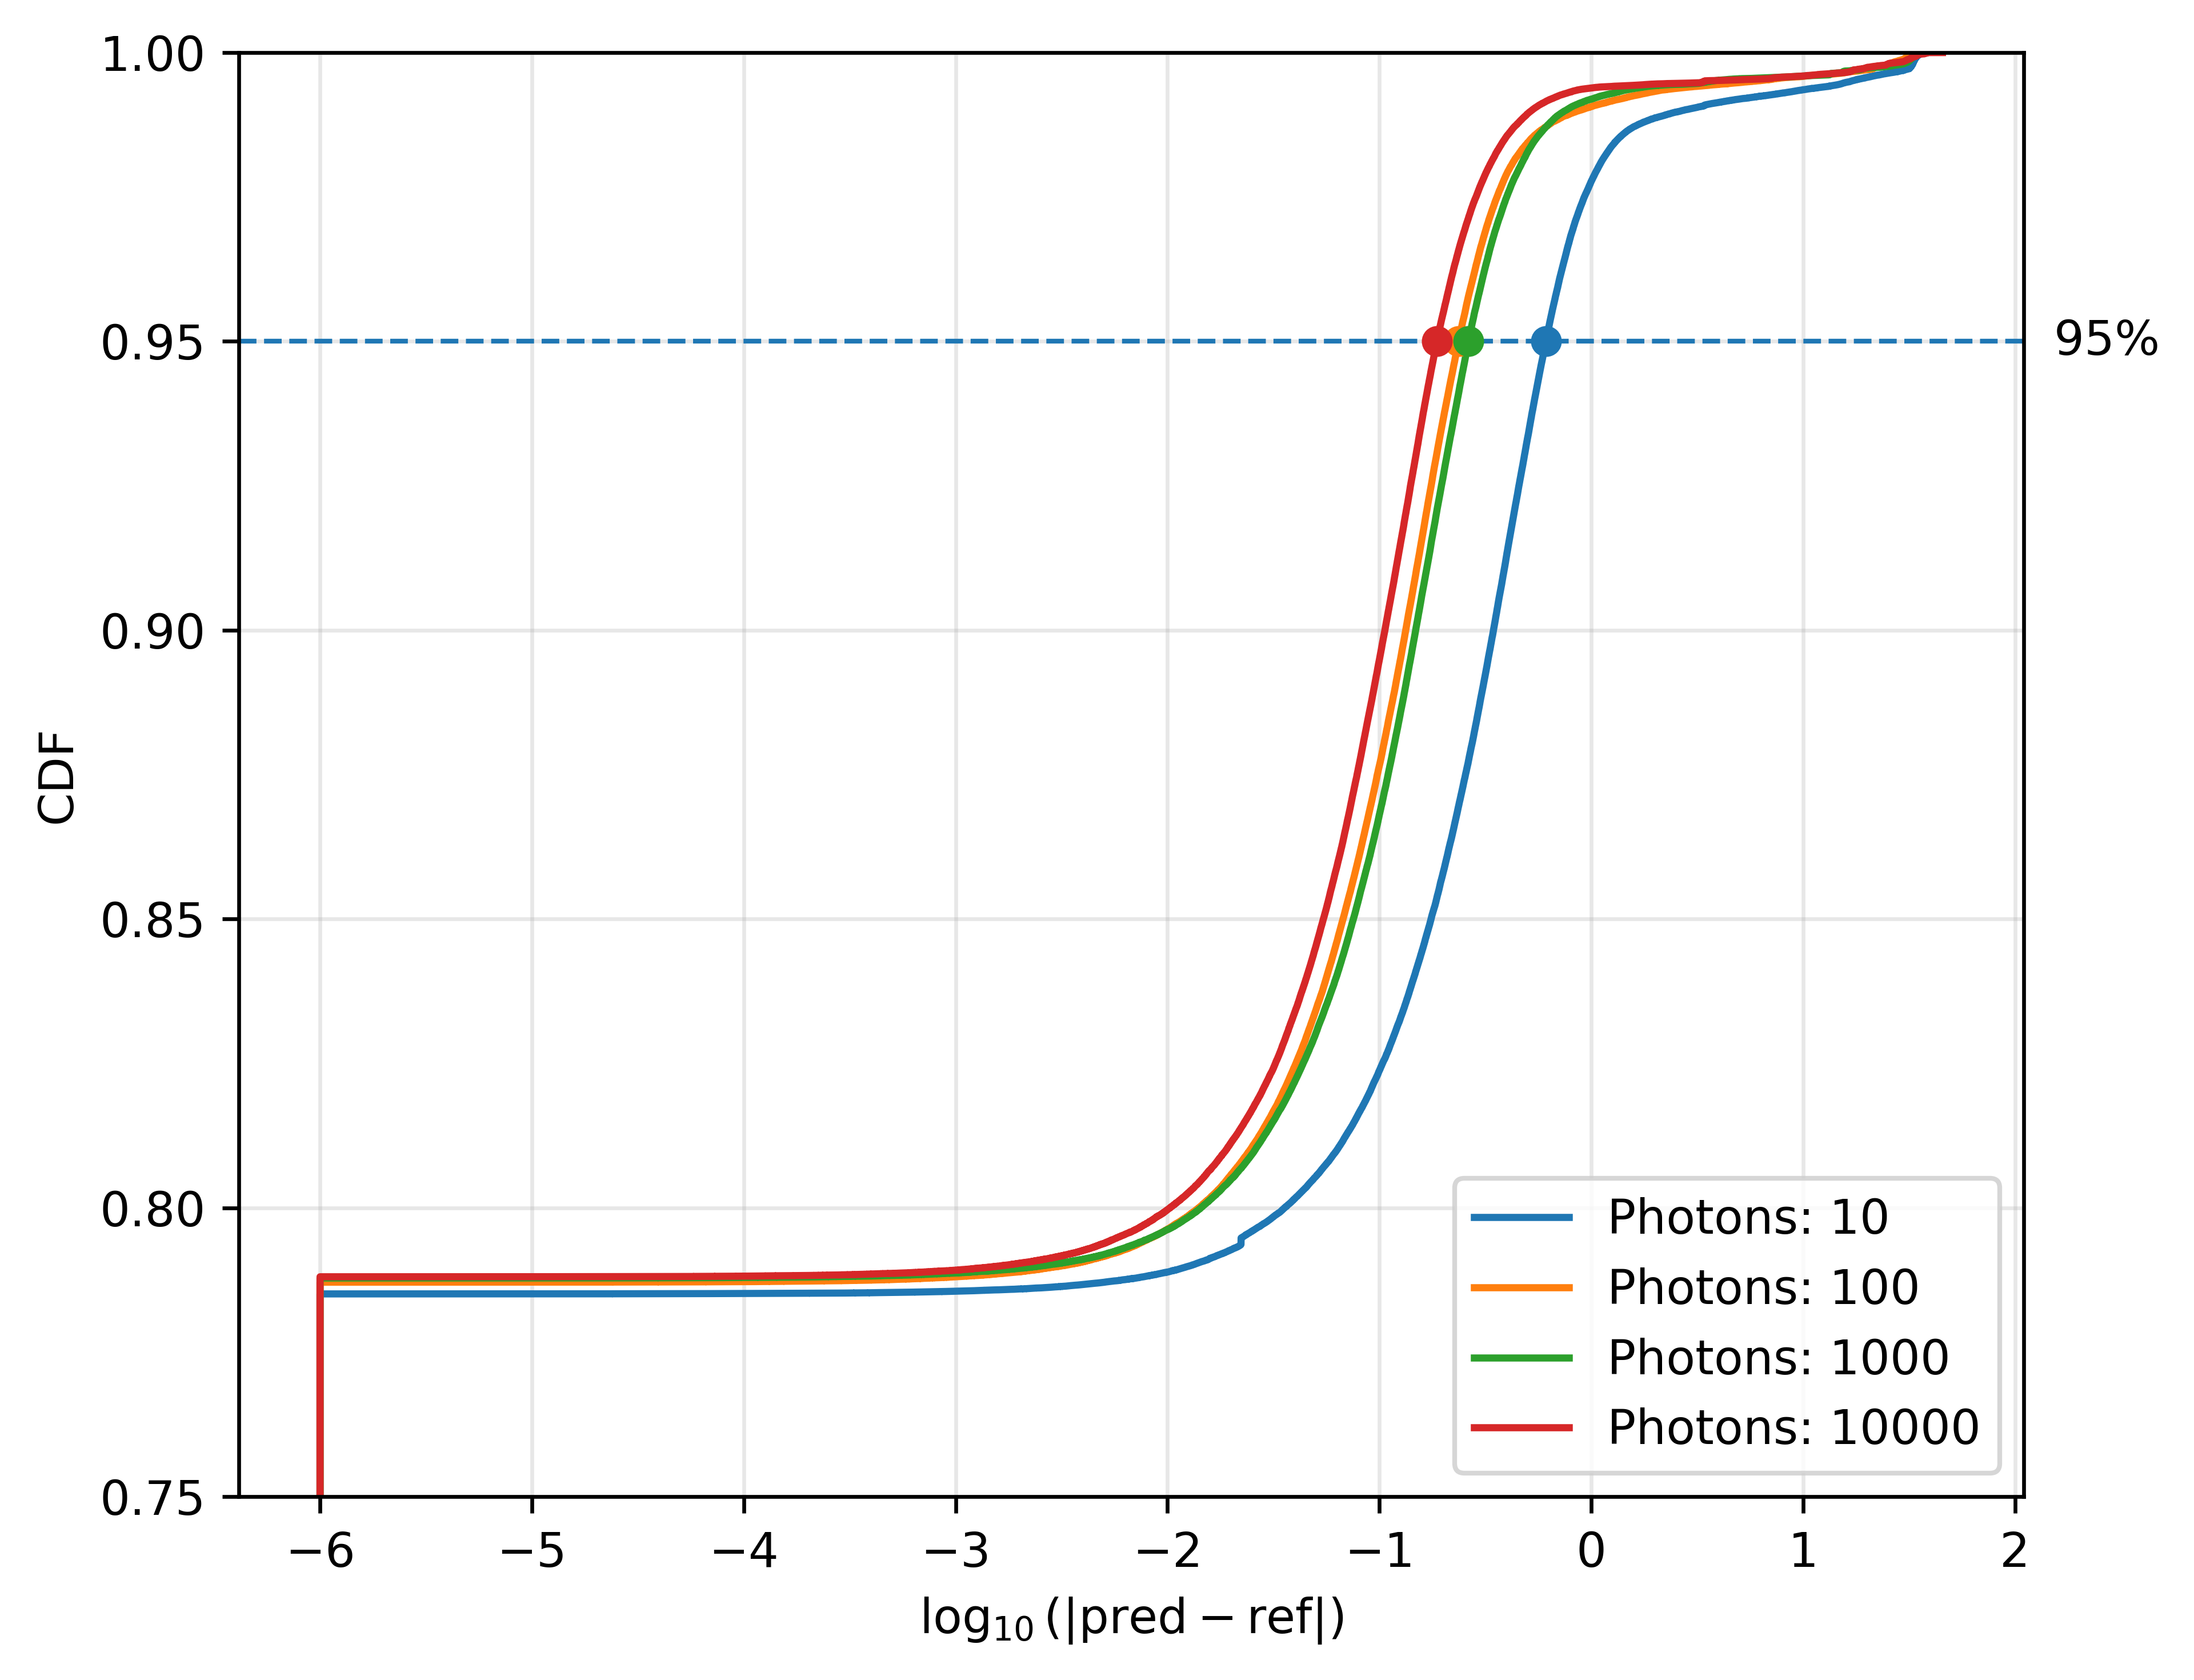

In [10]:
plt.figure(figsize=(6.5, 5), dpi=600)

eps = 1e-6
target = 0.95   

for p, ad in zip(patches, absdiff_list):
    v = ad.reshape(-1)
    v = v[np.isfinite(v)]
    v_sorted = np.sort(v + eps)
    cdf = np.arange(1, v_sorted.size + 1) / v_sorted.size

    x = np.log10(v_sorted)
    line, = plt.plot(x, cdf, label=f"Photons: {p}")

    # ---- CDF=0.95  ----
    err_at_target = np.interp(target, cdf, v_sorted)
    logerr_at_target = np.log10(err_at_target)

    # ---- 95% ----
    plt.scatter(
        logerr_at_target,
        target,
        s=30,
        color=line.get_color(),
        zorder=5
    )

    print(f"Photon: {p}: CDF=0.95 -> log10(err)={logerr_at_target:.6f}, err={err_at_target:.6e}")

plt.xlabel(r"$\log_{10}(|\mathrm{pred}-\mathrm{ref}|)$")
plt.ylabel("CDF")
plt.ylim(0.75, 1.0)

plt.axhline(y=target, linestyle='--', linewidth=1)

xmax = plt.xlim()[1]
plt.text(
    xmax,
    target,
    "  95%",
    va='center',
    ha='left'
)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()